In [ ]:
import math
import numpy as onp
import sympy as sp
from pathlib import Path
from typing import TypeVar, Generic, Protocol
import sys
_project_root: Path = Path.cwd().resolve()
sys.path.insert(0, str(_project_root.parents[1]))
import src.symmetry as sym
from src.categorization import show_latex_bmatrix, show_latex_eqn, latex_bmatrix_vec, cyclic_power_rep
from src.bases import CanonBasis4x4
from src.permutations import Permutation, PermutationGroup, PermElt
import src.permutations as perms
from src.categorization import display_char_table
NDArray = onp.ndarray

class Field(Protocol):
  def __mul__(self, other) -> 'Field': ...
  def __add__(self, other) -> 'Field': ...
  def __truediv__(self, other) -> 'Field': ...
  def conjugate(self) -> 'Field': ...
  

F = TypeVar('F', bound=Field)

class GaloisGroup(sym.FiniteGroupAction):
  pass

Gal = GaloisGroup


**Problem 1**

In [18]:
order = 175_560
sizes = onp.array([
  1, 1_463, 5_852, 5_852, 5_852, 29_260, 25_080, 17_556, 17_556, 15_960, 11_704, 11_704, 9_240, 9_240, 9_240,
])

χ_V = onp.array([
  76, 4, 1, 1, 1, 1, -1, -1, -1, -1, 1, 1, 0, 0, 0
])

print(onp.sum(sizes * χ_V**2)/order)

1.0


In [19]:
n = 9
print(order)
print(math.factorial(n))

175560
362880


**Problem 3** This problem concerns the thermodynamic behavior of a highly fluxional tetrahedral molecule or molecular cluster (e.e., $\mathrm{NH}_4^+$), where the four outer atoms constantly swap positions via quantum tunneling and thermal rearrangements.

Suppose that at each discrete time step, a structural fluctuation causes exactly one of the following two physical transitions to occur wiht equal probability:
- **Pairwise exchange:** Energy flucturations cause two of the four atoms to swap physical positions. The pair is chosen uniformly at random
- **Opposite-edge half-turn:** The molecule undergoe s a twist causing two distinct pairs of atoms to swap poitions simultaneously. The axis of rotation is chosen uniformly at ranodm.

(a) Write down the probability distribution $P:S_4\to [0,1]$ describing the structural rearrangement of the molecule after a single time step

(b) Compute the Fourier transform $\mathcal{F}(P)$

In [20]:
p = perms.perm_from_cycles(((1,2),), degree=4)

# print(perms.perm_hom(p))
S4 = PermutationGroup.symmetric(n=4)

W =  1 / S4.order * onp.diag([*S4.conjugacy_class_sizes().values()])
print(W * S4.order)
print(S4.conjugacy_class_sizes())

CL12 = perms.conjugacy_class(p, S4)
for g in CL12:
  print(perms.perm_hom(g))

print(S4.conjugacy_classes())
for g in S4.conjugacy_class_representatives():
  print(perms.perm_hom(g))



# print(perms.conjugacy_class(p, S4))

# G = perms.generated_group((p,))

# for g in G:
#   print(perms.perm_hom(g))

[[3. 0. 0. 0. 0.]
 [0. 8. 0. 0. 0.]
 [0. 0. 6. 0. 0.]
 [0. 0. 0. 6. 0.]
 [0. 0. 0. 0. 1.]]
{(1, 0, 3, 2): 3, (0, 2, 3, 1): 8, (1, 2, 3, 0): 6, (0, 1, 3, 2): 6, (0, 1, 2, 3): 1}
[[0 1 0 0]
 [1 0 0 0]
 [0 0 1 0]
 [0 0 0 1]]
[[0 0 1 0]
 [0 1 0 0]
 [1 0 0 0]
 [0 0 0 1]]
[[0 0 0 1]
 [0 1 0 0]
 [0 0 1 0]
 [1 0 0 0]]
[[1 0 0 0]
 [0 0 1 0]
 [0 1 0 0]
 [0 0 0 1]]
[[1 0 0 0]
 [0 0 0 1]
 [0 0 1 0]
 [0 1 0 0]]
[[1 0 0 0]
 [0 1 0 0]
 [0 0 0 1]
 [0 0 1 0]]
(((3, 2, 1, 0), (2, 3, 0, 1), (1, 0, 3, 2)), ((1, 3, 2, 0), (1, 2, 0, 3), (2, 1, 3, 0), (2, 0, 1, 3), (3, 1, 0, 2), (3, 0, 2, 1), (0, 2, 3, 1), (0, 3, 1, 2)), ((3, 2, 0, 1), (2, 3, 1, 0), (3, 0, 1, 2), (1, 2, 3, 0), (2, 0, 3, 1), (1, 3, 0, 2)), ((2, 1, 0, 3), (3, 1, 2, 0), (1, 0, 2, 3), (0, 2, 1, 3), (0, 3, 2, 1), (0, 1, 3, 2)), ((0, 1, 2, 3),))
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]
[[1 0 0 0]
 [0 1 0 0]
 [0 0 0 1]
 [0 0 1 0]]
[[1 0 0 0]
 [0 0 0 1]
 [0 1 0 0]
 [0 0 1 0]]
[[0 1 0 0]
 [1 0 0 0]
 [0 0 0 1]
 [0 0 1 0]]
[[0 0 0 1]
 [1 0 0 0]
 [0

A probability distribution $P$ on a finite group $G$ is a function $P:G\to [0,1]$ satisfying the *unitarity* axiom:
$$
\sum_{h\in G}P(h)=1.
$$
This can be interpreted as choosing a random group element $g\in G$ from a bag with the associated probability $P(g)$. Given a subset $A\subseteq G$, we define
$$
P(A):=\sum_{h\in A}P(h),
$$
which can be interpreted as the probability of choosing a group element from $A$ in a random draw. Hence, the unitarity axiom can be rephrased as $P(G)=1$.




In [ ]:
class CharG(Generic[F]):
  r""" Group does not determine a character; it only determines the domain and conjugacy classes """
  def __init__(self, data: dict[perms.Permutation, F], group: PermutationGroup):
    self.group = group
    self.class_reps = group.conjugacy_class_representatives()
    self.class_sizes = group.conjugacy_class_sizes()
    normed = {}
    for key, val in data.items():
      rep = perms.conjugacy_class_representative(key, group)
      if rep in normed and normed[rep] != val:
        raise ValueError(f"inconsistent values on class {rep!r}")
      normed[rep] = val

    missing = [rep for rep in self.class_reps if rep not in normed]
    if missing:
      raise ValueError(f"missing values for classes {missing!r}")

    # get_rep = lambda p: perms.conjugacy_class_representative(p, group)
    # normed = dict(zip(map(get_rep, data.keys()), data.values()))
    self.data = normed

  def __getitem__(self, key) -> F:
    rep = perms.conjugacy_class_representative(key, self.group)
    return self.data[rep]

  def __or__(self, other: 'CharG'):
    r""" Inner product on G!!! """
    return sum(
      self.class_sizes[rep] * onp.conj(self[rep]) * other[rep] 
      for rep in self.class_reps
    ) / self.group.order
  
  def values_on_classes(self):
    return [self[rep] for rep in self.class_reps]

  def decompose(self, irrep_table):
    return {
      name: (self|irrep)
      for name, irrep in irrep_table.items()
    }
  @classmethod
  def from_row(cls, row: list[F], group: PermutationGroup):
    reps = group.conjugacy_class_representatives()
    return cls(dict(zip(reps, row)), group)




In [ ]:

S4 = PermutationGroup.symmetric(4)


H_atoms = onp.arange(4)

table = {
  "U":   [1,  1,  1,  1,  1],
  "U'":  [1, -1,  1,  1, -1],
  "V":   [3,  1, -1,  0, -1],
  "V'":  [3, -1, -1,  0,  1],
  "W":   [2,  0,  2, -1,  0],
}

display_char_table(table)




dict_keys([(1, 1, 1, 1), (2, 1, 1), (3, 1), (2, 2), (4,)])


<IPython.core.display.Math object>

**Problem 4**

Consieder the group $\mathbb{F}$ parameterized by $\theta\in[0,2\pi)$ with the Haar integral

$$
f\mapsto\frac{1}{2\pi}\int_{0}^{2\pi} f(\theta)d\theta.
$$

Note that $\mathbb{F}$ acts on the vector space $\mathbb{C}[x,y]$ via 
$$
\theta\cdot p(x,y)=p((\cos\theta)x + (\sin\theta)y, (-\sin\theta)x + (\cos\theta)y).
$$
Moreoever, for every $d\in\mathbb{N}$, this action restricts to the subrepresentation

$$
\mathbb{C}^{(d)}[x,y] = \mathrm{span}\{x^d, x^{d-1}y,\dots, y^d\}
$$
of a degree $d$ homogeneous polynomial in two variables.

(a) Recall that the irreducible representations of $\mathbb{F}$ are of the form $U_n=\mathbb{C}$ for $n\in\mathbb{Z}$, where $e^{\theta i}\in\mathbb{F}$ acts via rotating $U_n$ clockwise by $n\theta$, i.e., multiplying by $e^{n\theta i}$. Decompose the representation $\mathbb{C}^{(3)}[x,y]$ as a direct sum of irreducible representations of $\mathbb{F}$.

Let $u:=x-iy$ and $v:=x+iy$, so we have the change of variables mapping
$$
(u, v) = M(x, y), \quad\text{where}\quad M = \begin{bmatrix} 1 & -i \\ 1 & i \end{bmatrix}
$$

$$
\theta\cdot (x-iy)
\big((\cos\theta)x+(\sin\theta)y\big)
-i\big(-(\sin\theta)x+(\cos\theta)y\big).
$$

In [10]:
x, y = sp.Symbol("y"), sp.Symbol("x")

def action(θ, x, y):
  return (onp.cos(θ) * x + onp.sin(θ) * y, -onp.sin(θ) * x + onp.cos(θ) * y)


M = onp.array([[1, -1j], [1, 1j]], dtype=onp.complex128)
uv = M @ onp.array([x,y])

display(onp.vectorize(sp.simplify)(uv))


array([-1.0*I*x + 1.0*y, 1.0*I*x + 1.0*y], dtype=object)

In [11]:
t = sp.Symbol("t")
ft = t**3 + t**2 - 6*t - 7
roots = tuple(sp.roots(ft).keys())
display(*tuple(map(sp.simplify, roots)))
display(*roots)
disc = 1
for j in range(3):
  for i in range(j):
    disc *= (roots[i] - roots[j])
display(sp.simplify(disc))


g19 = perms.perm_from_cycles(((1, 2, 3, 4, 5), (6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19),))
M19 = perms.generated_group((g19,))
print(M19.conjugacy_class_sizes().values())

-1/3 + 19**(2/3)*2**(1/3)/(3*(7 + 3*sqrt(3)*I)**(1/3)) + 76**(1/3)*(7 + 3*sqrt(3)*I)**(1/3)/6

19**(2/3)*(-2*2**(1/3)/3 + (-4 + 2**(2/3)*(-1 + sqrt(3)*I)*(133 + 57*sqrt(3)*I)**(1/3))*(1 - sqrt(3)*I)*(133 + 57*sqrt(3)*I)**(1/3)/228)/((1 - sqrt(3)*I)*(7 + 3*sqrt(3)*I)**(1/3))

19**(2/3)*(-2*2**(1/3)/3 + (-4 + 2**(2/3)*(-1 - sqrt(3)*I)*(133 + 57*sqrt(3)*I)**(1/3))*(1 + sqrt(3)*I)*(133 + 57*sqrt(3)*I)**(1/3)/228)/((1 + sqrt(3)*I)*(7 + 3*sqrt(3)*I)**(1/3))

-1/3 + 19/(9*(133/54 + 19*sqrt(3)*I/18)**(1/3)) + (133/54 + 19*sqrt(3)*I/18)**(1/3)

-1/3 + 19/(9*(-1/2 + sqrt(3)*I/2)*(133/54 + 19*sqrt(3)*I/18)**(1/3)) + (-1/2 + sqrt(3)*I/2)*(133/54 + 19*sqrt(3)*I/18)**(1/3)

-1/3 + (-1/2 - sqrt(3)*I/2)*(133/54 + 19*sqrt(3)*I/18)**(1/3) + 19/(9*(-1/2 - sqrt(3)*I/2)*(133/54 + 19*sqrt(3)*I/18)**(1/3))

(-399*sqrt(3) - 133*2**(2/3)*I*(133 + 57*sqrt(3)*I)**(1/3)/2 - 19*722**(1/3)*I*(7 + 3*sqrt(3)*I)**(2/3)/2 - 133*sqrt(3)*722**(1/3)*(7 + 3*sqrt(3)*I)**(2/3)/18 - 209*2**(2/3)*sqrt(3)*(133 + 57*sqrt(3)*I)**(1/3)/18 + 209*sqrt(3)*(532 + 228*sqrt(3)*I)**(1/3)/18 + 133*2**(1/3)*sqrt(3)*(133 + 57*sqrt(3)*I)**(2/3)/18 + 209*I + 19*2**(1/3)*I*(133 + 57*sqrt(3)*I)**(2/3)/2 + 133*I*(532 + 228*sqrt(3)*I)**(1/3)/2)/(21*sqrt(3) - 11*I)

dict_values([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


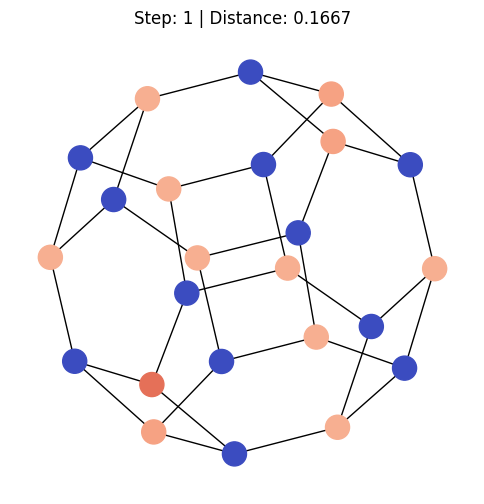

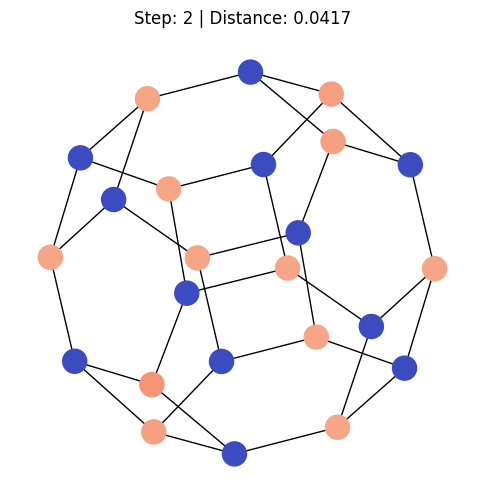

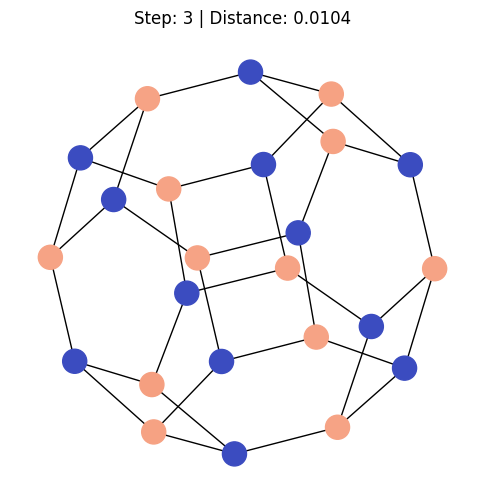

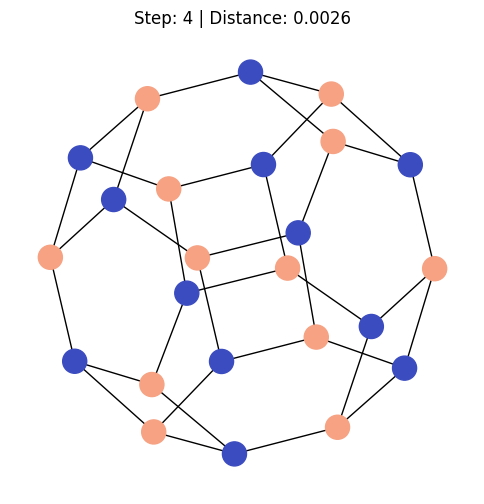

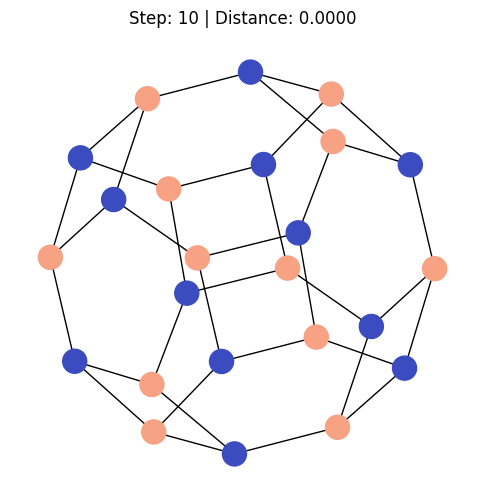

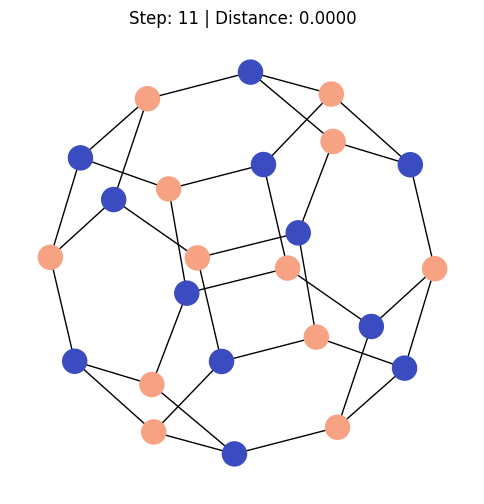

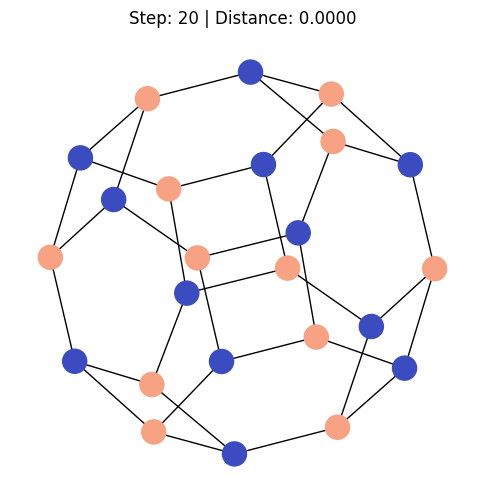

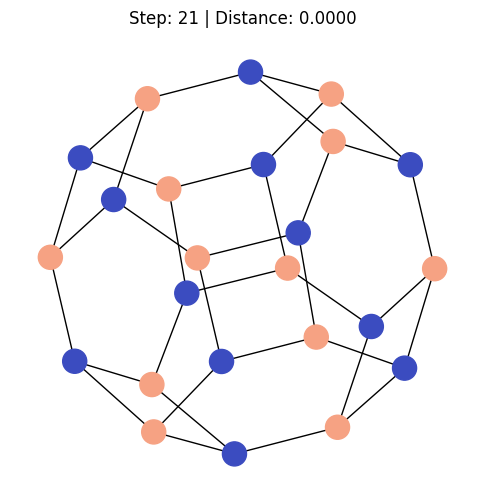

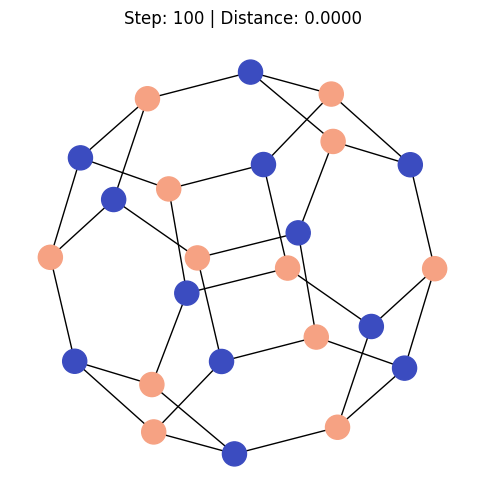

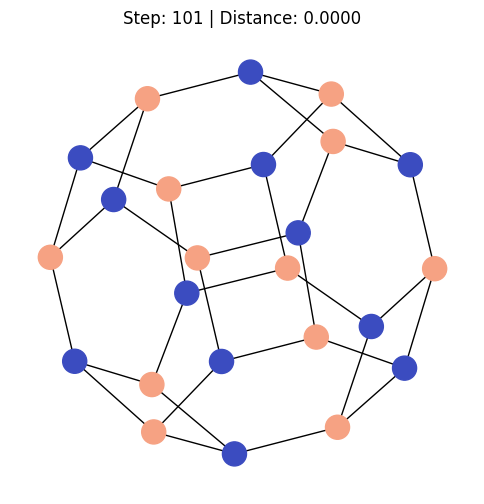

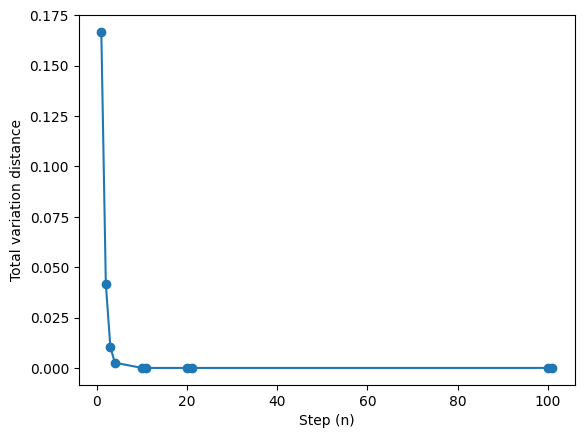

In [ ]:
import importlib
import networkx as nx
import matplotlib.pyplot as plt
# perms = importlib.reload(perms)
# PermutationGroup = perms.PermutationGroup

def cayley_graph(G, generators):
  H = nx.Graph()
  H.add_nodes_from(G)
  e = perms.identity_perm(G.degree)
  for s in generators:
    if s != e:
      for g in G:
        H.add_edge(g, perms.compose(s, g))
  return H
def visualize_walk(G, step_dist, steps, *, target=None):
    e = perms.identity_perm(G.degree)
    gens = G.generators or tuple(g for g, p in step_dist.items() if p > 0 and g != e)
    graph = cayley_graph(G, gens)
    pos = nx.kamada_kawai_layout(graph)
    cmap = plt.get_cmap("coolwarm")
    dists = []

    for n in sorted(steps):
        Pn = perms.power_dist(G, step_dist, n)
        u = 1.0 / G.order
        nodes = sorted(G)
        colors = []
        for g in nodes:
            p = Pn[g]
            if abs(p - u) < 1e-15:
                t = 0.5
            elif p < u:
                t = 0.5 * (p / u) ** 0.25
            else:
                t = 0.5 + 0.5 * ((p - u) / (1 - u)) ** 0.25
            colors.append(cmap(t))

        d = perms.variation_distance(Pn, target, G)
        dists.append((n, d))
        fig, ax = plt.subplots(figsize=(6, 6))
        nx.draw_networkx(graph, pos=pos, nodelist=nodes, node_color=colors, with_labels=False, node_size=300, ax=ax)
        ax.set_title(f"Step: {n} | Distance: {d:.4f}")
        ax.axis("off")
        display(fig)
        plt.close(fig)

    fig, ax = plt.subplots()
    ax.plot([n for n, _ in dists], [d for _, d in dists], marker="o")
    ax.set_xlabel("Step (n)")
    ax.set_ylabel("Total variation distance")
    display(fig)
    plt.close(fig)

# Example 9.5
G = perms.Cn(5)
g = G.generators[0]
P = perms.dist(G, [(0.5, g), (0.5, perms.inverse(g))])
P_limit = None

# Example 9.9
G = perms.An(4)
c123 = perms.from_cycle_notation("(1,2,3)", degree=4)
conj_class = G.conjugacy_class(c123)
P = perms.dist(G, [(0.25, g) for g in conj_class])
P_limit = None

# Example 9.10
G = PermutationGroup.symmetric(4)
three_cycles = [g for g in G if perms.cycle_type(g) == (3, 1)]
two_two_cycles = [g for g in G if perms.cycle_type(g) == (2, 2)]
e = perms.identity_perm(G.degree)
P = perms.dist(G, [(0.25, e)] + [(1/16, g) for g in three_cycles] + [(1/12, g) for g in two_two_cycles])
P_limit = {g: (2 / G.order if perms.sgn(g) == 1 else 0.0) for g in G}

visualize_walk(G, P, [1, 2, 3, 4, 10, 11, 20, 21, 100, 101], target=P_limit)


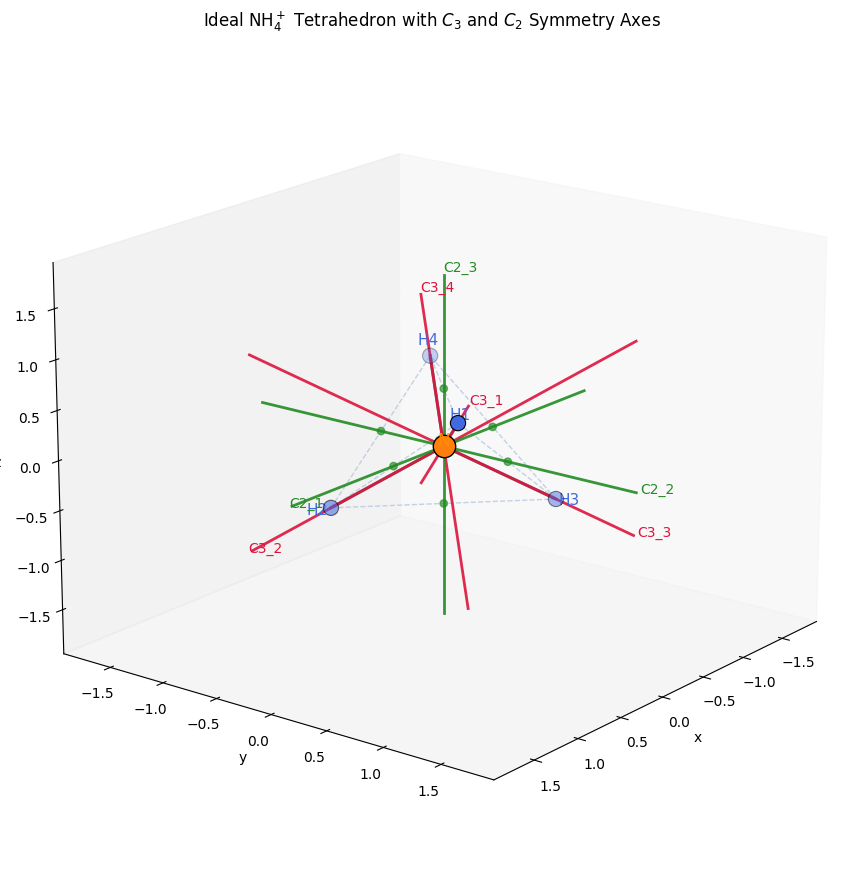

In [14]:
from itertools import combinations
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def regular_tetrahedron_vertices(bond_length: float = 1.0) -> NDArray:
  r"""Hydrogen positions for an ideal tetrahedral NH4+ centered at the origin."""
  verts = onp.array([
    [ 1.0,  1.0,  1.0],
    [ 1.0, -1.0, -1.0],
    [-1.0,  1.0, -1.0],
    [-1.0, -1.0,  1.0],
  ], dtype=float)
  verts /= onp.linalg.norm(verts[0])
  return bond_length * verts

def tetrahedron_edges() -> tuple[tuple[int, int], ...]:
  return tuple(combinations(range(4), 2))

def opposite_edge_pairs() -> tuple[tuple[tuple[int, int], tuple[int, int]], ...]:
  return (
    ((0, 1), (2, 3)),
    ((0, 2), (1, 3)),
    ((0, 3), (1, 2)),
  )

def face_center(vertices: NDArray, omit: int) -> NDArray:
  face = onp.array([vertices[j] for j in range(4) if j != omit])
  return face.mean(axis=0)

def axis_segment(direction: NDArray, length: float = 1.65) -> NDArray:
  direction = onp.asarray(direction, dtype=float)
  direction /= onp.linalg.norm(direction)
  return onp.vstack([-length * direction, length * direction])

def set_axes_equal(ax):
  xlim = onp.array(ax.get_xlim3d())
  ylim = onp.array(ax.get_ylim3d())
  zlim = onp.array(ax.get_zlim3d())
  spans = onp.array([xlim[1] - xlim[0], ylim[1] - ylim[0], zlim[1] - zlim[0]])
  centers = onp.array([xlim.mean(), ylim.mean(), zlim.mean()])
  radius = 0.5 * spans.max()
  ax.set_xlim3d(centers[0] - radius, centers[0] + radius)
  ax.set_ylim3d(centers[1] - radius, centers[1] + radius)
  ax.set_zlim3d(centers[2] - radius, centers[2] + radius)

def plot_nh4_symmetry(
  bond_length: float = 1.0,
  axis_length: float = 1.7,
  show_labels: bool = True,
  show_face_centers: bool = False,
):
  r"""Plot an ideal NH4+ tetrahedron with the main rotational symmetry axes.

  Axes shown:
  - 4 C3 axes through each H atom and the opposite face center
  - 3 C2 axes through the midpoints of opposite H-H edges
  """
  H = regular_tetrahedron_vertices(bond_length=bond_length)
  N = onp.zeros(3)
  fig = plt.figure(figsize=(9, 9))
  ax = fig.add_subplot(111, projection='3d')

  for i, h in enumerate(H, start=1):
    ax.plot(
      [N[0], h[0]], [N[1], h[1]], [N[2], h[2]],
      color='dimgray', lw=2.2, zorder=1,
    )
    if show_labels:
      ax.text(*(1.12 * h), f'H{i}', color='royalblue', fontsize=11, ha='center')

  for i, j in tetrahedron_edges():
    ax.plot(
      [H[i, 0], H[j, 0]], [H[i, 1], H[j, 1]], [H[i, 2], H[j, 2]],
      color='lightsteelblue', lw=1.0, ls='--', alpha=0.75, zorder=0,
    )

  ax.scatter(*N, s=260, color='tab:orange', edgecolor='black', linewidth=1.0, zorder=4)
  ax.scatter(H[:, 0], H[:, 1], H[:, 2], s=120, color='royalblue', edgecolor='black', linewidth=0.8, zorder=5)
  if show_labels:
    ax.text(*(1.08 * N), 'N', color='darkorange', fontsize=12, ha='center')

  for i, h in enumerate(H, start=1):
    seg = axis_segment(h, length=axis_length)
    ax.plot(seg[:, 0], seg[:, 1], seg[:, 2], color='crimson', lw=2.0, alpha=0.9)
    if show_labels:
      ax.text(*(1.02 * seg[1]), f'C3_{i}', color='crimson', fontsize=10)
    if show_face_centers:
      fc = face_center(H, i - 1)
      ax.scatter(*fc, s=45, color='crimson', alpha=0.55)

  for k, ((i, j), (m, n)) in enumerate(opposite_edge_pairs(), start=1):
    mid_ij = 0.5 * (H[i] + H[j])
    mid_mn = 0.5 * (H[m] + H[n])
    direction = mid_ij - mid_mn
    seg = axis_segment(direction, length=axis_length)
    ax.plot(seg[:, 0], seg[:, 1], seg[:, 2], color='forestgreen', lw=2.0, alpha=0.9)
    if show_labels:
      ax.text(*(1.02 * seg[1]), f'C2_{k}', color='forestgreen', fontsize=10)
    ax.scatter(
      [mid_ij[0], mid_mn[0]], [mid_ij[1], mid_mn[1]], [mid_ij[2], mid_mn[2]],
      s=28, color='forestgreen', alpha=0.65,
    )

  lim = 1.95 * bond_length
  ax.set_xlim(-lim, lim)
  ax.set_ylim(-lim, lim)
  ax.set_zlim(-lim, lim)
  set_axes_equal(ax)
  ax.set_xlabel('x')
  ax.set_ylabel('y')
  ax.set_zlabel('z')
  ax.set_title(r'Ideal $\mathrm{NH}_4^+$ Tetrahedron with $C_3$ and $C_2$ Symmetry Axes')
  ax.view_init(elev=18, azim=38)
  ax.grid(False)
  fig.tight_layout()
  return fig, ax, H

fig, ax, H = plot_nh4_symmetry(show_face_centers=False)
plt.show()
